# **Analyse et Ingénierie des données de la chlordécone aux Antilles françaises**

# Notebook 3 – Transformation, Recodage & Agrégation

## Objectifs de ce notebook
- Recoder et transformer les variables
- Extraire et manipuler les données temporelles
- Agréger les données par commune, sol, année
- Utiliser des structures de contrôle (if/else, switch, boucles for/while, apply/map/lapply)
- Réaliser des jointures et analyser leur impact sur la structure des données
- Créer de nouvelles variables utiles pour l'analyse (équivalent mutate)
- Effectuer du Text Mining sur les noms de communes

## 1. Import & chargement du fichier nettoyé

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Utilisation de chemins relatifs pour la reproductibilité
DATA_DIR = os.path.join('..', 'data', 'sorted')
FIG_DIR  = os.path.join('..', 'fig', '3-transformation_agregation')
os.makedirs(FIG_DIR, exist_ok=True)  # Crée le dossier de figures s'il n'existe pas

# Chargement du dataset nettoyé précédemment
df = pd.read_csv(
    os.path.join(DATA_DIR, 'BaseCLD2026_clean.csv'),
    parse_dates=['Date_prelevement', 'Date_enregistrement', 'Date_analyse']
)
print(f'\n Données nettoyées chargées : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')

## 2. Transformation des variables temporelles

In [ ]:
# Extraction des composantes temporelles
# Équivalent de mutate() en dplyr : création de nouvelles colonnes dans le DataFrame
df['mois_prelevement']      = df['Date_prelevement'].dt.month    # Numéro du mois (1-12)
df['trimestre_prelevement'] = df['Date_prelevement'].dt.quarter  # Trimestre (1-4)
df['saison_prelevement']    = df['mois_prelevement'].map({       # Mapping mois → saison antillaise
    1: 'Carême', 2: 'Carême', 3: 'Carême', 4: 'Carême',
    5: 'Hivernage', 6: 'Hivernage', 7: 'Hivernage', 8: 'Hivernage',
    9: 'Hivernage', 10: 'Hivernage', 11: 'Carême', 12: 'Carême'
})

print('Variables temporelles créées (mutate) :')
print(df[['Date_prelevement', 'mois_prelevement', 'trimestre_prelevement', 'saison_prelevement']].head(5))

## 3. Recodage des variables

In [ ]:
# 3.1 Catégorisation du taux de chlordécone
# Seuils réglementaires : 0.1 mg/kg (alerte), 1 mg/kg (restriction)
def categoriser_taux(taux): # Fonction pour catégoriser le taux de chlordécone
    if pd.isna(taux): # Si le taux est manquant
        return np.nan # On le classe comme 'Inconnu'
    elif taux < 0.1:
        return '🟢 Faible (< 0.1)'
    elif taux < 1.0:
        return '🟡 Modéré (0.1–1.0)'
    else:
        return '🔴 Élevé (≥ 1.0)'

df['categorie_contamination'] = df['Taux_Chlordecone'].apply(categoriser_taux) # Application de la fonction de catégorisation sur nos données

print('Catégories de contamination créées :')
print(df['categorie_contamination'].value_counts())

Catégories de contamination créées :
categorie_contamination
🟢 Faible (< 0.1)      20334
🔴 Élevé (≥ 1.0)        5564
🟡 Modéré (0.1–1.0)     5228
Name: count, dtype: int64


C:\Users\patxi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\patxi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\patxi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


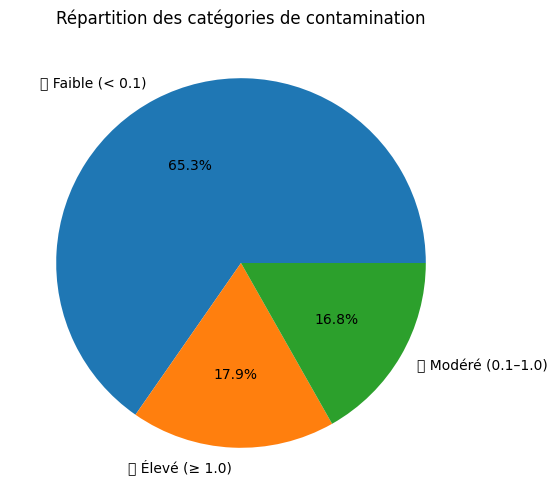

In [ ]:
# Répartition de nos catégories de taux
cat_cont = df['categorie_contamination'].value_counts()

# Représentation sous forme de diagramme circulaire
plt.figure(figsize=(8, 6))
plt.pie(cat_cont.values, labels=cat_cont.index, autopct='%1.1f%%') # Affiche les pourcentages sur le graphique de ce que représente chaque catégorie
plt.title('Répartition des catégories de contamination')
plt.show()

Cela nous permet d'avoir un rapide aperçu du poids de chaque catégorie de taux dans nos données.

In [ ]:
# 3.2 Recodage de la pluviométrie (RAIN) en variable ordinale
# Équivalent de mutate() en dplyr : création d'une nouvelle colonne recodée
rain_order = {
    '0-1250'   : 1,
    '1250-1500': 2,
    '1500-2000': 3,
    '2000-3000': 4,
    '3000-5000': 5,
    '5000-8000': 6
}
df['RAIN_ordinal'] = df['RAIN'].map(rain_order)  # mutate : nouvelle colonne ordinale
print('RAIN recodé en variable ordinale (mutate) :')
print(df[['RAIN', 'RAIN_ordinal']].drop_duplicates().sort_values('RAIN_ordinal'))

**Utilisation du Switch en Python équivalent match/case**

In [ ]:
# Fonction de SWITCH pour décrire les catégories de RAIN
def description_rain(groupe):
    match groupe:
        case '0-1250':    return 'Zone sèche'
        case '1250-1500': return 'Zone semi-aride'
        case '1500-2000': return 'Zone modérée'
        case '2000-3000': return 'Zone humide'
        case '3000-5000': return 'Zone très humide'
        case '5000-8000': return 'Zone extrêmement humide'
        case _:           return 'Inconnu'

# Application de la fonction de description sur la colonne RAIN
df['description_rain'] = df['RAIN'].apply(description_rain)

**Utilisation du WHILE**

In [ ]:
# Boucle while : calcul du seuil qui couvre 90% des observations
seuil = 0.0
pct   = 0.0
while pct < 90.0:
    seuil += 0.1
    pct = (df['Taux_Chlordecone'] <= seuil).mean() * 100 # Calcule le pourcentage d'observations inférieures ou égales au seuil actuel

print(f'Seuil couvrant 90% des observations : {seuil:.1f} mg/kg')

Seuil couvrant 90% des observations : 2.6 mg/kg


In [ ]:
# 3.3 Log-transformation du taux de chlordécone et du taux de 5b_hydro
# Équivalent de mutate() en dplyr : transformation et création de nouvelles variables
# log1p gère les valeurs de 0 (log1p(x) = log(1+x))
df['log_Taux_Chlordecone'] = np.log1p(df['Taux_Chlordecone'])  # mutate
df['log_Taux_5b_hydro']    = np.log1p(df['Taux_5b_hydro'])     # mutate

print('Variables log-transformées créées (mutate).')
print(df[['Taux_Chlordecone', 'log_Taux_Chlordecone', 'Taux_5b_hydro', 'log_Taux_5b_hydro']].head(5))

## 4. Structures de contrôle – Boucles & Apply

In [ ]:
# 4.1 Résumé par variable numérique via boucle "for"
num_cols = ['Taux_Chlordecone', 'Taux_5b_hydro', 'mnt_pente_mean', 'mnt_tpi_mean'] # Liste des variables numériques que nous allons résumer
print('Résumé rapide des variables numériques clés :\n')
for col in num_cols:
    moy = df[col].mean() # Moyenne
    med = df[col].median() # Médiane
    std = df[col].std() # Ecart-type
    
    if moy > med * 2: # Si la moyenne représente plus du double de la médiane, on considère que la distribution est asymétrique à droite
        distribution = 'asymétrique droite'
    elif moy < med * 0.5: # Si la moyenne représente moins de la moitié de la médiane, on considère que la distribution est asymétrique à gauche
        distribution = 'asymétrique gauche'
    else:
        distribution = 'approximativement symétrique' # Sinon on considère que la distribution est relativement symétrique
    
    # Affichage pour nos colonnes numériques, la moyenne, la médiane, l'écart-type et la forme de la distribution
    print(f'  [{col}]')
    print(f'    Moyenne={moy:.4f}  Médiane={med:.4f}  Écart-type={std:.4f} → {distribution}\n')

Résumé rapide des variables numériques clés :

  [Taux_Chlordecone]
    Moyenne=0.6677  Médiane=0.0033  Écart-type=1.5599 → asymétrique droite

  [Taux_5b_hydro]
    Moyenne=4.5354  Médiane=0.0033  Écart-type=67.0269 → asymétrique droite

  [mnt_pente_mean]
    Moyenne=20.2650  Médiane=17.9023  Écart-type=13.3681 → approximativement symétrique

  [mnt_tpi_mean]
    Moyenne=0.2117  Médiane=0.1200  Écart-type=2.5783 → approximativement symétrique



In [ ]:
# 4.2 Utilisation de apply + lambda 
# Créer une variable de risque combiné
def score_risque(row):
    """Score combiné basé sur le taux, la pente et la pluviométrie."""
    score = 0 # Initialisation du score à 0
    score += row['log_Taux_Chlordecone'] * 2 # Poids taux
    score += row.get('mnt_pente_mean', 0) / 100 # Poids pente
    score += row.get('RAIN_ordinal', 0) * 0.3 # Poids pluie
    return round(score, 4) 

df['score_risque'] = df.apply(score_risque, axis=1) # On applique la fonction de calcul du score de risque à notre dataframe
print('Score de risque calculé via apply.')
print(df['score_risque'].describe()) # On affiche le détail statistique après application

Score de risque calculé via apply.
count    31126.000000
mean         1.941070
std          1.190357
min          0.302000
25%          1.268725
50%          1.481350
75%          2.076100
max          7.558700
Name: score_risque, dtype: float64


**Équivalents Python de `lapply` et `sapply` (R)**

In [ ]:
# Équivalent de lapply() en R → map() sur une liste de colonnes
# lapply retourne une liste de résultats, un par élément
cols_num = ['Taux_Chlordecone', 'Taux_5b_hydro', 'log_Taux_Chlordecone', 'log_Taux_5b_hydro']

# map() applique describe() à chaque colonne → liste de Series (comme lapply)
resultats_lapply = list(map(lambda col: df[col].describe(), cols_num))
print('=== Équivalent lapply() – describe() par colonne ===')
for col, stats in zip(cols_num, resultats_lapply):
    print(f'\n[{col}]')
    print(stats)

# Équivalent de sapply() en R → dict comprehension (résultat aplati, une valeur par colonne)
# sapply simplifie le résultat en vecteur/matrice
moyennes_sapply = {col: round(df[col].mean(), 4) for col in cols_num}
print('\n=== Équivalent sapply() – moyenne par colonne ===')
for col, moy in moyennes_sapply.items():
    print(f'  {col} : {moy}')

## 5. Agrégations – GroupBy & Summarise

In [ ]:
# 5.1 Agrégation par commune
agg_commune = df.groupby('COMMU_LAB').agg( # Agrégation par commune
    nb_prelevements   = ('ID', 'count'), # Nombre de prélèvements par commune
    taux_moyen_chlor  = ('Taux_Chlordecone', 'mean'), # Moyenne du taux de chlordécone par commune
    taux_median_chlor = ('Taux_Chlordecone', 'median'), # Médiane du taux de chlordécone par commune
    taux_max_chlor    = ('Taux_Chlordecone', 'max'), # Taux maximum de chlordécone par commune
    pct_contamines    = ('categorie_contamination', lambda x: (x != '🟢 Faible (< 0.1)').mean() * 100) # Pourcentage de prélèvements contaminés (non "faible") par commune
).round(3).sort_values('taux_moyen_chlor', ascending=False).reset_index() 

print('Agrégation par commune (Top 10 les plus contaminées) :')
agg_commune.head(10) # Affichage des 10 communes les plus contaminées selon le taux moyen de chlordécone

Agrégation par commune (Top 10 les plus contaminées) :


,COMMU_LAB,nb_prelevements,taux_moyen_chlor,taux_median_chlor,taux_max_chlor,pct_contamines
0,MORNE-ROUGE(LE),3725,2.800,2.758,17.350,68.913
1,GRAND'RIVIERE,125,1.840,0.336,15.515,54.400
2,MACOUBA,698,1.697,1.500,5.310,89.828
3,BASSE-POINTE,992,1.381,0.090,9.300,48.185
4,TRINITE(LA),1101,0.684,0.060,3.600,44.777
5,MARIGOT(LE),475,0.613,0.125,2.000,50.316
6,LORRAIN(LE),1763,0.584,0.185,12.779,60.976
7,SAINT-PIERRE,339,0.561,0.005,4.131,43.068
8,GROS-MORNE,2093,0.547,0.003,5.770,27.903
9,LAMENTIN(LE),1930,0.442,0.003,5.672,24.974


In [ ]:
# 5.2 Agrégation par année
agg_annee = df.groupby('ANNEE').agg( # Agrégation par année
    nb_prelevements  = ('ID', 'count'), # Nombre de prélèvements par année
    taux_moyen       = ('Taux_Chlordecone', 'mean'), # Moyenne du taux de chlordécone par année
    taux_median      = ('Taux_Chlordecone', 'median'), # Médiane du taux de chlordécone par année
    score_moyen      = ('score_risque', 'mean') # Moyenne du score de risque par année
).round(4).reset_index()

# Rangé par odre chronologique
agg_annee = agg_annee.sort_values('ANNEE')
print('Évolution annuelle :')
agg_annee

Évolution annuelle :


,ANNEE,nb_prelevements,taux_moyen,taux_median,score_moyen
0,2010,3928,2.7782,2.6500,3.7356
1,2011,1163,1.3894,0.1100,2.3799
2,2012,1479,0.4954,0.0200,1.8657
3,2013,1562,0.3682,0.0033,1.7967
4,2014,1153,0.3697,0.0800,1.7662
5,2015,3158,0.5204,0.0033,1.7837
6,2016,4316,0.2191,0.0033,1.5190
7,2017,5141,0.5291,0.0060,1.8647
8,2018,8567,0.1120,0.0020,1.4500
9,2019,659,0.3805,0.1160,1.7844


In [ ]:
# 5.3 Agrégation par type de sol et pluviométrie
agg_sol_pluie = (
    df.groupby(['Sol_simple_imputed', 'RAIN'])['Taux_Chlordecone']
    .mean().round(3).unstack()
)

plt.figure(figsize=(12, 5))
sns.heatmap(agg_sol_pluie, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5)
plt.title('Taux moyen de Chlordécone par type de sol et pluviométrie', fontsize=13, fontweight='bold')
plt.xlabel('Groupe de pluviométrie (mm/an)')
plt.ylabel('Type de sol')
plt.tight_layout()
# Chemin relatif pour la reproductibilité
plt.savefig(os.path.join(FIG_DIR, 'fig_heatmap_sol_pluie.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Extraction de sous-ensembles & Filtres

In [ ]:
# 6.1 Parcelles à contamination élevée (≥ 1 mg/kg)
df_contamines = df[df['Taux_Chlordecone'] >= 1.0].copy() # Sous-ensemble des parcelles avec un taux de chlordécone supérieur ou égal à 1 mg/kg
print(f'🔴 Parcelles à contamination élevée : {len(df_contamines):,} observations ({len(df_contamines)/len(df)*100:.1f}%)')

# 6.2 Sous-ensemble : Andosols en zone très pluvieuse
df_andosol_pluie = df[
    (df['Sol_simple_imputed'] == 'Andosol') & # Sous-ensemble des parcelles de type Andosol
    (df['RAIN'].isin(['3000-5000', '5000-8000'])) # 
].copy()
print(f'🌧️ Andosols en zone très pluvieuse : {len(df_andosol_pluie):,} observations')

# 6.3 Parcelles avec historique bananier connu
df_banane = df[df['histo_banane_flag'] == 1].copy()
print(f'🍌 Parcelles avec historique bananier : {len(df_banane):,} observations')

🔴 Parcelles à contamination élevée : 5,564 observations (17.9%)
🌧️ Andosols en zone très pluvieuse : 4,016 observations
🍌 Parcelles avec historique bananier : 13,143 observations


## 7. Jointure de données – Enrichissement avec les agrégats commune

In [ ]:
# Left join : on enrichit le df principal avec le classement par commune
agg_commune_rank = agg_commune[['COMMU_LAB', 'taux_moyen_chlor', 'pct_contamines']].copy() # On sélectionne uniquement les colonnes nécessaires pour le join
agg_commune_rank.columns = ['COMMU_LAB', 'commune_taux_moyen', 'commune_pct_contamines'] # On renomme les colonnes pour éviter les conflits de noms lors du merge

# Left Join pour lier notre dataframe principal avec les informations agrégées par commune (taux moyen de chlordécone et pourcentage de prélèvements contaminés)
df_enriched = df.merge(agg_commune_rank, on='COMMU_LAB', how='left')

print(f'Left join réalisé. Dimensions : {df_enriched.shape}')
print(f'Lignes avec commune_taux_moyen renseigné : {df_enriched["commune_taux_moyen"].notna().sum():,}')

Left join réalisé. Dimensions : (31126, 35)
Lignes avec commune_taux_moyen renseigné : 30,828


**Différentes jointures possibles**

On crée un petit DataFrame de référence pour illustrer les jointures


In [ ]:
# On garde seulement 20 communes pour illustrer l'impact des jointures
df_ref = agg_commune_rank.head(20)

# Left join → toutes les lignes de df, NaN si la commune n'est pas dans df_ref
left  = df.merge(df_ref, on='COMMU_LAB', how='left')

# Right join → seulement les communes de df_ref, NaN si pas de parcelles correspondantes
right = df.merge(df_ref, on='COMMU_LAB', how='right')

# Inner join → uniquement les parcelles dont la commune est dans df_ref
inner = df.merge(df_ref, on='COMMU_LAB', how='inner')

# Full (outer) join → toutes les lignes des deux côtés, NaN là où il n'y a pas de correspondance
full  = df.merge(df_ref, on='COMMU_LAB', how='outer')

print(f'df original  : {len(df):,} lignes')
print(f'Left join    : {len(left):,} lignes  → même nb que df, toutes les parcelles conservées')
print(f'Right join   : {len(right):,} lignes  → limité aux 20 communes de df_ref')
print(f'Inner join   : {len(inner):,} lignes  → seulement les parcelles présentes dans les 2 tables')
print(f'Full join    : {len(full):,} lignes  → union totale, NaN là où pas de correspondance')

# --- Analyse de l'impact des jointures ---
print('\n=== Analyse de l\'impact des jointures sur les données ===')

# Lignes perdues avec inner join
pertes_inner = len(df) - len(inner)
print(f'\n[Inner join] Perte de {pertes_inner:,} lignes ({pertes_inner/len(df)*100:.1f}%)')
print('  → Les parcelles hors des 20 communes sélectionnées sont exclues.')
print('  → Risque de biais si les communes exclues ont un profil de contamination différent.')

# NaN introduits par le left join
nan_left = left['commune_taux_moyen'].isna().sum()
print(f'\n[Left join] {nan_left:,} lignes avec NaN dans commune_taux_moyen')
print('  → Parcelles dont la commune n\'est pas dans df_ref : données enrichissement manquantes.')
print('  → Avantage : aucune observation originale n\'est perdue.')

# Lignes supplémentaires avec full join
surplus_full = len(full) - len(df)
print(f'\n[Full join] {surplus_full:,} lignes supplémentaires par rapport au df original')
print('  → Communes de df_ref sans parcelles associées génèrent des lignes à NaN.')
print('  → Utile pour repérer les communes référencées mais sans données terrain.')

## 8. Visualisations de synthèse

In [ ]:
# 8.1 Évolution temporelle du taux moyen
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(agg_annee['ANNEE'], agg_annee['taux_moyen'],
             marker='o', color='coral', linewidth=2, label='Moyenne')
axes[0].plot(agg_annee['ANNEE'], agg_annee['taux_median'],
             marker='s', color='steelblue', linewidth=2, linestyle='--', label='Médiane')
axes[0].set_title('Évolution du Taux de Chlordécone (2010–2019)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Année')
axes[0].set_ylabel('Taux (mg/kg)')
axes[0].legend()

# 8.2 Répartition des catégories de contamination
cat_counts = df['categorie_contamination'].value_counts()
colors_pie = ['#2ecc71', '#f39c12', '#e74c3c']
axes[1].pie(
    cat_counts.values,
    labels=[c.split('(')[0] for c in cat_counts.index],
    colors=colors_pie,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Répartition des niveaux de contamination', fontsize=12, fontweight='bold')

plt.tight_layout()
# Chemin relatif pour la reproductibilité
plt.savefig(os.path.join(FIG_DIR, 'fig_evolution_categories.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 8.3 Top 15 des communes les plus contaminées
top15 = agg_commune.head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    top15['COMMU_LAB'][::-1],
    top15['taux_moyen_chlor'][::-1],
    color=plt.cm.YlOrRd(np.linspace(0.3, 0.9, 15))
)
ax.axvline(x=1.0, color='red',    linestyle='--', linewidth=1.5, label='Seuil restriction (1.0 mg/kg)')
ax.axvline(x=0.1, color='orange', linestyle='--', linewidth=1.5, label='Seuil alerte (0.1 mg/kg)')
ax.set_title('Top 15 communes avec le taux moyen de Chlordécone le plus élevé', fontsize=13, fontweight='bold')
ax.set_xlabel('Taux moyen (mg/kg)')
ax.legend()
plt.tight_layout()
# Chemin relatif pour la reproductibilité
plt.savefig(os.path.join(FIG_DIR, 'fig_top15_communes.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Text mining

In [ ]:
## 8. Text Mining – Analyse des noms de communes

# Nettoyage des noms de communes pour une analyse textuelle plus robuste
df['commune_clean'] = df['COMMU_LAB'].str.upper().str.strip()

df_saints = df[df['commune_clean'].str.contains('SAINT', na=False)] # Sous-ensemble des communes contenant "SAINT" ou "SAINTE"
print(f'Communes avec SAINT/SAINTE : {df_saints["commune_clean"].nunique()} communes, {len(df_saints):,} parcelles')

df['prefixe'] = df['commune_clean'].str.extract(r'\((LE|LA|LES)\)') # Extraction des préfixes "LE", "LA", "LES" entre parenthèses dans les noms de communes
print(df['prefixe'].value_counts(dropna=False))

# Analyse de la fréquence des mots dans les noms de communes
from collections import Counter
# On concatène tous les noms de communes uniques, on les split en mots individuels et on compte la fréquence de chaque mot pour identifier les plus courants
tous_mots = ' '.join(df['commune_clean'].dropna().unique()).split()
print(Counter(tous_mots).most_common(10))

Communes avec SAINT/SAINTE : 7 communes, 5,986 parcelles
prefixe
NaN    15824
LE     13808
LA      1101
LES      393
Name: count, dtype: int64
[('GROS-MORNE', 1), ('DUCOS', 1), ('SAINTE-MARIE', 1), ('LORRAIN(LE)', 1), ('ROBERT(LE)', 1), ('VAUCLIN(LE)', 1), ('FRANCOIS(LE)', 1), ('TRINITE(LA)', 1), ('SAINT-PIERRE', 1), ('FONDS-SAINT-DENIS', 1)]


Les résultats **"NaN"** correspondent aux communes sans préfixe, soit ici 15824.

## 10. Export final

In [ ]:
# Export du dataset final (chemin relatif pour la reproductibilité)
OUT_DIR = os.path.join('..', 'data', 'sorted')
os.makedirs(OUT_DIR, exist_ok=True)

df_enriched.to_csv(os.path.join(OUT_DIR, 'BaseCLD2026_transformed.csv'), index=False)
agg_commune.to_csv(os.path.join(OUT_DIR, 'agg_par_commune.csv'), index=False)
agg_annee.to_csv(os.path.join(OUT_DIR, 'agg_par_annee.csv'), index=False)

print('Fichiers exportés :')
print(f'  - {os.path.join(OUT_DIR, "BaseCLD2026_transformed.csv")}  (dataset principal enrichi)')
print(f'  - {os.path.join(OUT_DIR, "agg_par_commune.csv")}          (agrégats par commune)')
print(f'  - {os.path.join(OUT_DIR, "agg_par_annee.csv")}            (agrégats par année)')

print(f'\nDimensions finales : {df_enriched.shape}')
df_enriched.head(3)

Au sein de ces 3 notebook, nous avons pu réaliser le **chargement et l'exploiration des données** (Notebook 1), leur **nettoyage et imputation** (Notebook 2) ainsi que leur **transformation et la mise en place d'agrégat** (Notebook 3).

Nous allons à présent pouvoir passer aux deuxième volet qui consiste à effectuer des analyses statistiques et des visualisations avancées.